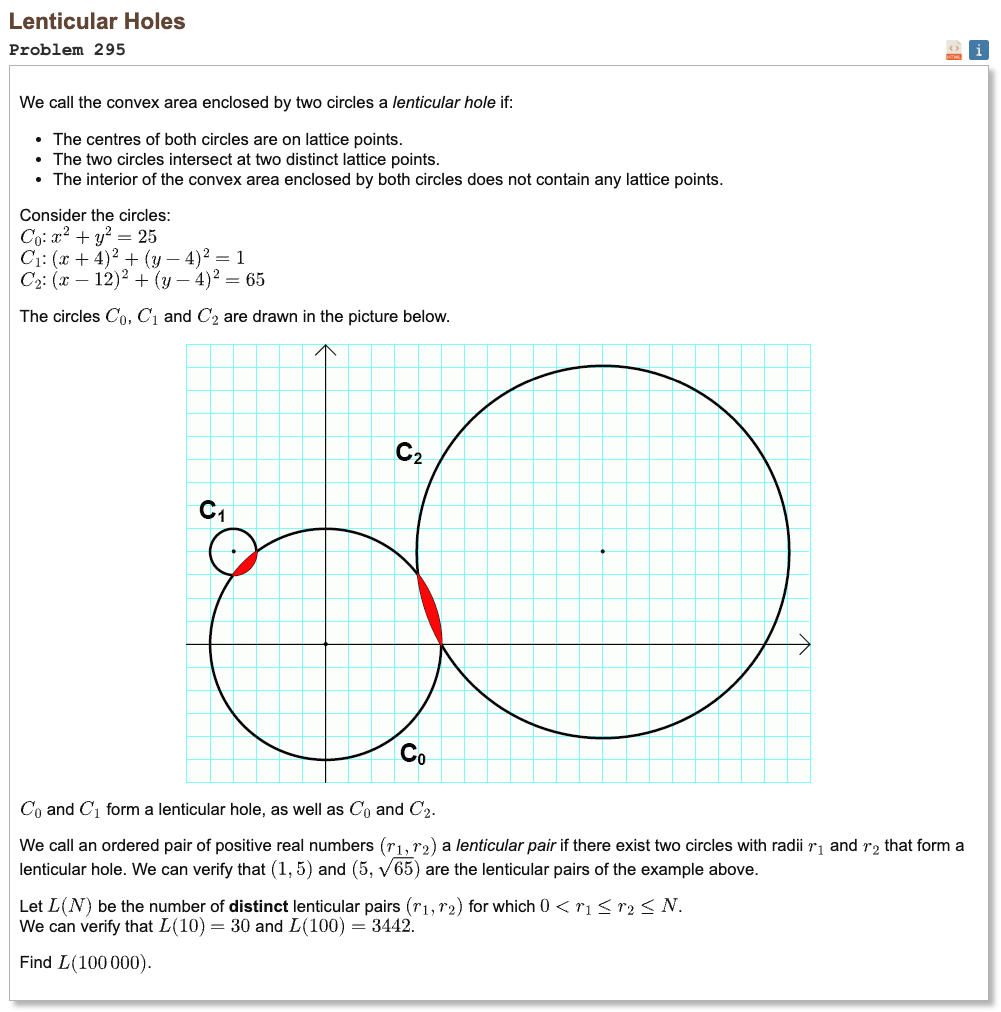

## Initial approach

* start from the common chord of the two circles, because the two lattice intersection points tell you almost everything about the shape
* that chord direction must be primitive, otherwise there would already be extra lattice points sitting on the chord inside the lens, so those cases are impossible
* once that primitive direction is fixed, the possible circles that use it can be indexed by one odd size parameter, so the problem becomes generating valid radius values instead of searching arbitrary circle pairs
* for a fixed chord type, there is a first odd size where the symmetric lens becomes empty of interior lattice points, and after that, larger choices stay valid because the overlap only gets thinner
* so for each chord type, find that first valid odd size, then generate every radius value up to the bound
* store for each radius squared which chord types can produce it, because two radii form a lenticular pair exactly when their chord type sets overlap
* then count all radius pairs through those set overlaps instead of testing circle pairs directly, which is the step that makes the whole search feasible for one hundred thousand 

In [1]:
import math

def egcd(a, b):
    if b == 0:
        return a, 1, 0
    g, x1, y1 = egcd(b, a % b)
    return g, y1, x1 - (a // b) * y1

def t_interval(u, v, ax, ay, r2, x0, y0):
    s = u * u + v * v
    dx = x0 - ax
    dy = y0 - ay
    a = s
    b = 2 * (u * dx + v * dy)
    c = dx * dx + dy * dy - r2
    d = b * b - 4 * a * c
    if d <= 0:
        return None
    sqrt_d = math.isqrt(d)
    q2 = 2 * a
    p1 = -b - sqrt_d
    p2 = -b + sqrt_d
    t_min = -((-p1) // q2)
    t_max = (p2 - 1) // q2
    if t_min > t_max:
        return None
    return t_min, t_max

def line_has_point(u, v, m, k, p, q):
    s = u * u + v * v
    ax = (u - m * v) // 2
    ay = (v + m * u) // 2
    bx = (u + m * v) // 2
    by = (v - m * u) // 2
    r2 = s * (1 + m * m) // 4
    x0 = -k * q
    y0 = k * p
    ia = t_interval(u, v, ax, ay, r2, x0, y0)
    if ia is None:
        return False
    ib = t_interval(u, v, bx, by, r2, x0, y0)
    if ib is None:
        return False
    t_min = max(ia[0], ib[0])
    t_max = min(ia[1], ib[1])
    return t_min <= t_max

def min_m_for_rep(u, v, m_max):
    s = u * u + v * v
    g, p, q = egcd(u, v)
    if g != 1:
        return None
    m = 1
    while m <= m_max:
        k_max = int(math.floor(s / (2.0 * (math.sqrt(1 + m * m) + m))))
        if k_max == 0:
            return m
        ok = True
        for k in range(1, k_max + 1):
            if line_has_point(u, v, m, k, p, q):
                ok = False
                break
        if ok:
            return m
        m += 2
    return None

def add_s(mapping, r2, s):
    val = mapping.get(r2)
    if val is None:
        mapping[r2] = s
        return
    if isinstance(val, int):
        if val == s:
            return
        if val < s:
            mapping[r2] = (val, s)
        else:
            mapping[r2] = (s, val)
        return
    if s in val:
        return
    mapping[r2] = val + (s,)

def intersects(a, b):
    i = 0
    j = 0
    while i < len(a) and j < len(b):
        if a[i] == b[j]:
            return True
        if a[i] < b[j]:
            i += 1
        else:
            j += 1
    return False

def compute_l(n):
    s_limit = 4 * n
    max_uv = math.isqrt(s_limit)
    s_to_reps = {}

    for u in range(1, max_uv + 1, 2):
        u2 = u * u
        v_limit = math.isqrt(s_limit - u2)
        for v in range(1, v_limit + 1, 2):
            if math.gcd(u, v) != 1:
                continue
            s = u2 + v * v
            if s > s_limit:
                continue
            s_to_reps.setdefault(s, []).append((u, v))

    r_map = {}

    for s, reps in s_to_reps.items():
        m_max_sq = (4 * n * n) // s - 1
        if m_max_sq < 1:
            continue
        m_max = math.isqrt(m_max_sq)
        if m_max < 1:
            continue

        m0 = None
        for u, v in reps:
            m_rep = min_m_for_rep(u, v, m_max)
            if m_rep is None:
                continue
            if m0 is None or m_rep < m0:
                m0 = m_rep

        if m0 is None:
            continue

        for m in range(m0, m_max + 1, 2):
            r2 = s * (1 + m * m) // 4
            add_s(r_map, r2, s)

    single_count = {}
    multi_count = {}

    for val in r_map.values():
        if isinstance(val, int):
            single_count[val] = single_count.get(val, 0) + 1
        else:
            sset = tuple(sorted(val))
            multi_count[sset] = multi_count.get(sset, 0) + 1

    total = 0

    for c in single_count.values():
        total += c * (c + 1) // 2

    for c in multi_count.values():
        total += c * (c + 1) // 2

    for sset, c in multi_count.items():
        total += c * sum(single_count.get(s, 0) for s in sset)

    multi_items = list(multi_count.items())
    for i in range(len(multi_items)):
        sset_i, c_i = multi_items[i]
        for j in range(i + 1, len(multi_items)):
            sset_j, c_j = multi_items[j]
            if intersects(sset_i, sset_j):
                total += c_i * c_j

    return total

assert compute_l(10) == 30
assert compute_l(100) == 3442

In [2]:
%%time
result = compute_l(100000)
print("Result:", result)

Result: 4884650818
CPU times: user 28.3 s, sys: 170 ms, total: 28.5 s
Wall time: 28.7 s
